# Clustering Methods

**Agenda**
1. K-Means Clustering
   - Steps of the K-Means algorithm
   - Choosing the optimal number of clusters
      - Elbow Method
      - Silhouette Score
      - Calinski-Harabasz Index (Variance Ratio Criterion)
   - Advantages of K-Means
   - Disadvantages of K-Means

2. K-Medoids
   - Steps of K-Medoids algorithm
   - Difference from K-Means (use of medoids instead of centroids)
   - Handling outliers and non-Euclidean distances
   - Pros and cons of K-Medoids compared to K-Means

3. Use Case: Customer Segmentation in E-commerce

## K-Means Clustering

- K-Means is a popular clustering algorithm that partitions data into K clusters, where each data point belongs to the cluster with the nearest centroid (mean).
- The algorithm iteratively assigns data points to clusters and updates centroids until convergence, aiming to minimize the sum of squared distances between data points and their cluster centroids.
- K-Means clustering enables us to divide data into distinct groups, helping to automatically identify categories within an unlabeled dataset without requiring prior training or labeled data.
- The below diagram explains the working of the K-means Clustering Algorithm:

   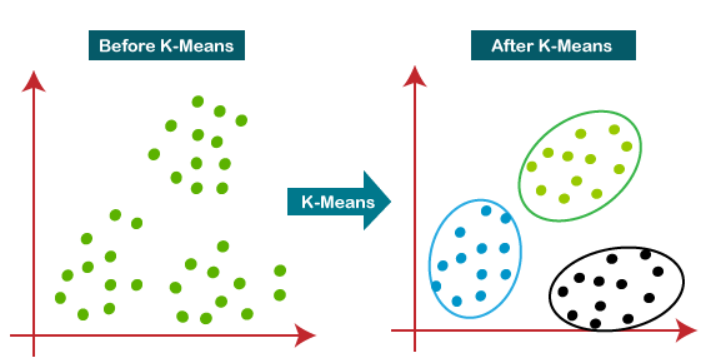

### Steps of the K-Means Algorithm

#### Initialization


- **Choose the number of clusters (K):** Determine how many clusters you want to form based on prior knowledge or methods like the Elbow Method.
- **Initialize centroids:** Randomly select K data points from the dataset to serve as the initial centroids. Alternatively, use K-Means++ for smarter initialization to enhance convergence speed and reduce the likelihood of poor clustering.

- Example: If you have a dataset of 100 points and want to divide it into 3 clusters, you randomly select 3 points as initial centroids.

**We'll initialize the dataset and choose the number of clusters (K). For simplicity, let's use 3 clusters.**

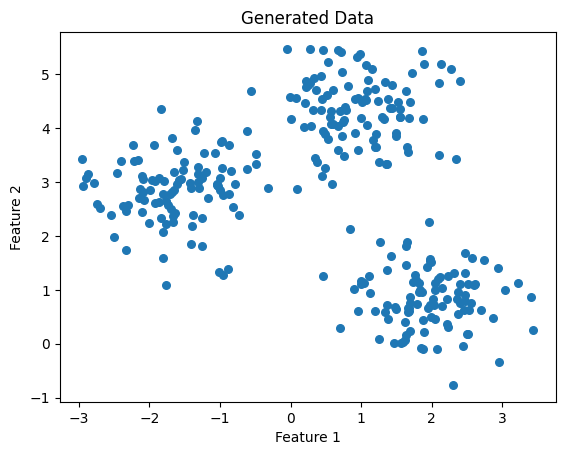

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Step 1: Generate synthetic data
n_samples = 300
n_clusters = 3
X, y = make_blobs(n_samples=n_samples, centers=n_clusters, cluster_std=0.60, random_state=0) #  It creates a dataset with multiple clusters by generating points around pre-defined cluster centers.

# Initial plot of the dataset
plt.scatter(X[:, 0], X[:, 1], s=30)
plt.title('Generated Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


#### Cluster Assignment

- For each data point in the dataset, calculate its distance to each centroid using a distance metric (commonly Euclidean distance).
- Assign each data point to the cluster associated with the nearest centroid. This results in the formation of K clusters based on proximity to the centroids.
- Mathematically, for each data point x<sub>i</sub> :

   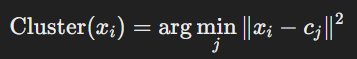

- where
c<sub>j</sub> is the centroid of cluster j and ∥⋅∥ <sup>2</sup> represents the squared Euclidean distance.

**In this step, we’ll calculate the distance of each data point from the centroids and assign each point to the nearest centroid.**

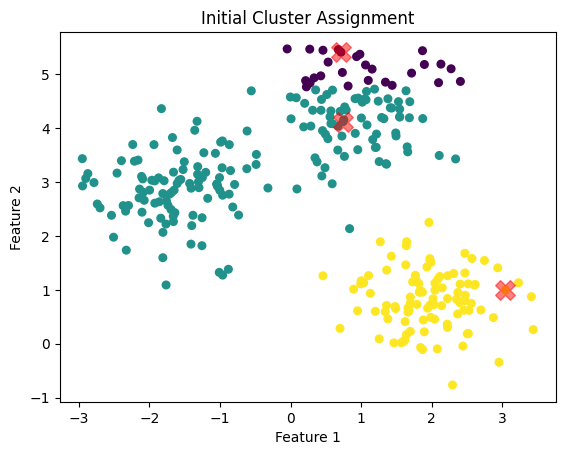

In [ ]:
# Step 2: Assignment Step
def assign_clusters(X, centroids):
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)  # Compute distances
    return np.argmin(distances, axis=1)  # Assign clusters based on closest centroid

# Randomly initialize centroids
np.random.seed(0)
initial_centroids = X[np.random.choice(X.shape[0], n_clusters, replace=False)]

# Assign clusters based on initial centroids
clusters = assign_clusters(X, initial_centroids)

# Visualizing the initial assignment
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=30, cmap='viridis')
plt.scatter(initial_centroids[:, 0], initial_centroids[:, 1], c='red', s=200, alpha=0.5, marker='X')
plt.title('Initial Cluster Assignment')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


#### Centroid Update

- After assigning all points to clusters, recalculate the centroids of each cluster by taking the mean of all data points in that cluster.

- New centroids are calculated as:

   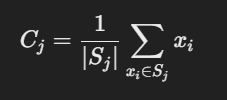

- where
S<sub>j</sub> represents the set of points in cluster
j, and
C<sub>j</sub> is the new centroid.

**We will calculate the new centroids based on the assigned clusters.**

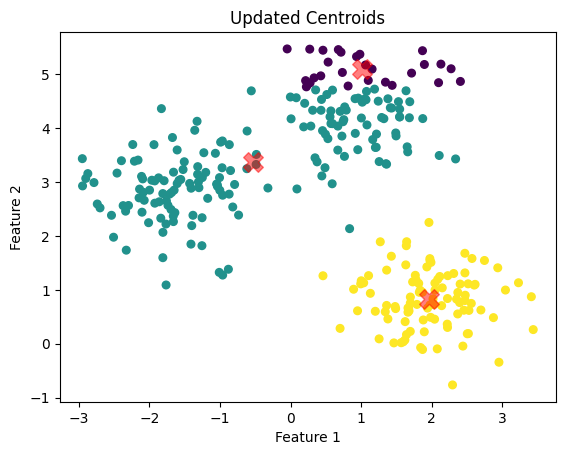

In [ ]:
# Step 3: Update Step
def update_centroids(X, clusters, n_clusters):
    return np.array([X[clusters == k].mean(axis=0) for k in range(n_clusters)])  # Calculate new centroids

# Calculate new centroids
new_centroids = update_centroids(X, clusters, n_clusters)

# Visualizing the updated centroids
plt.scatter(X[:, 0], X[:, 1], c=clusters, s=30, cmap='viridis')
plt.scatter(new_centroids[:, 0], new_centroids[:, 1], c='red', s=200, alpha=0.5, marker='X')
plt.title('Updated Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


#### Convergence

- Repeat the Assignment and Update steps until convergence is reached. - Convergence can occur in two ways:
   - The centroids no longer change significantly (i.e., their positions stabilize).
   - The assignments of data points to clusters no longer change.
- Typically, a threshold is set for the maximum allowable change in centroids or the maximum number of iterations is defined to prevent infinite loops.

**Now we will iterate through the Assignment and Update steps until the centroids no longer change significantly.**

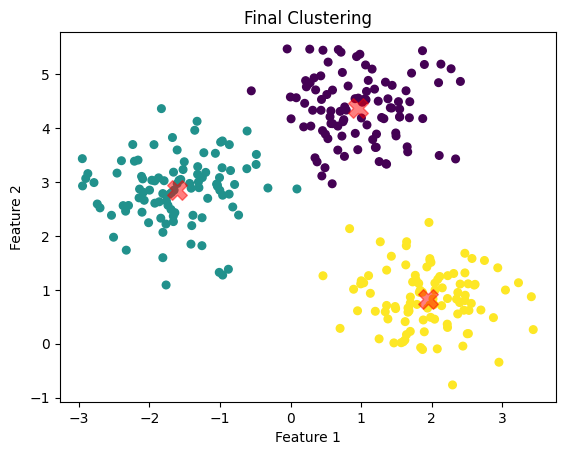

In [ ]:
# Step 4: K-Means Iteration
def k_means(X, n_clusters, max_iters=100):
    np.random.seed(0)
    centroids = X[np.random.choice(X.shape[0], n_clusters, replace=False)]  # Initialize centroids
    for _ in range(max_iters):
        clusters = assign_clusters(X, centroids)  # Assignment step
        new_centroids = update_centroids(X, clusters, n_clusters)  # Update step
        # Check for convergence (if centroids do not change)
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids
    return centroids, clusters

final_centroids, final_clusters = k_means(X, n_clusters)

# Visualizing final results
plt.scatter(X[:, 0], X[:, 1], c=final_clusters, s=30, cmap='viridis')
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c='red', s=200, alpha=0.5, marker='X')
plt.title('Final Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()


- The final plot will show the clustered data points with the centroids marked, indicating the final assignment of data points to clusters.

### Choosing the optimal number of clusters

- Choosing the optimal number of clusters (K) in the K-Means algorithm is crucial because an inappropriate number of clusters can lead to poor clustering performance. Several methods can help you determine the best value for K.
- Here’s an in-depth explanation of these methods:

#### Elbow Method

- The Elbow Method is one of the most popular techniques for determining the optimal number of clusters.
- It focuses on the Within-Cluster Sum of Squares (WCSS), also known as inertia, which measures the total squared distance between each data point and its assigned centroid.

**Steps:**
   - Run K-Means clustering for different values of K (e.g., K = 1 to 10).
   - Compute the WCSS for each K.
   - Plot the WCSS against the values of K.
   - Look for the "elbow" point in the graph, where the reduction in WCSS slows down significantly. This point indicates the optimal number of clusters because adding more clusters beyond this point doesn’t significantly improve the clustering.

**Code Example for Elbow Method:**

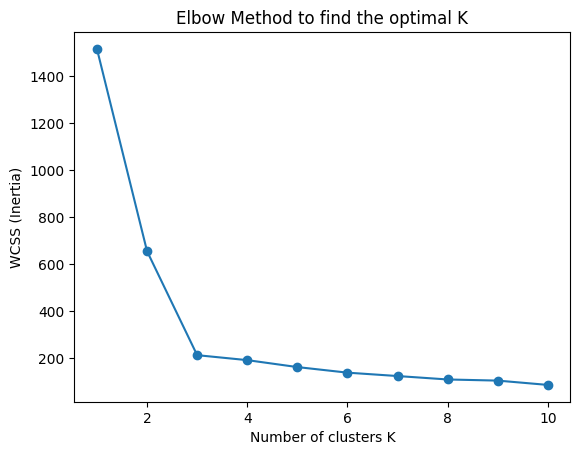

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate WCSS for different values of K
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)  # WCSS (inertia) for each K

# Plotting the WCSS to visualize the Elbow
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method to find the optimal K')
plt.xlabel('Number of clusters K')
plt.ylabel('WCSS (Inertia)')
plt.show()


**What we conclude from the above graph?**
- The plot shows a steep decline in WCSS as K increases from 1 to about 3, and then flattens out after that, the elbow point may be around
K=3.

- The elbow point at K=3 suggests that 3 clusters are optimal for this dataset. This means that increasing the number of clusters beyond 3 yields diminishing returns in terms of reducing the WCSS.

- By choosing K=3, we achieve a good balance between clustering performance (tightly grouped clusters) and model complexity (fewer clusters means simpler models). Using more clusters could lead to overfitting, where the model captures noise rather than the underlying structure.

- A smaller number of clusters (like 3) is often easier to interpret and analyze compared to a larger number of clusters. It allows for a more straightforward understanding of the data and helps in making informed decisions based on the identified clusters.

####  Silhouette Score

- The Silhouette Score evaluates how well each data point fits into its cluster compared to other clusters.
- It calculates the mean intra-cluster distance (how similar the points are within a cluster) and the mean nearest-cluster distance (how different the points are from the nearest other cluster).

**Silhouette Score Ranges:**

   - +1: Data points are well clustered.
   - 0: Data points are on or very close to the decision boundary between two clusters.
   - -1: Data points are assigned to the wrong clusters.
   
**Steps:**
   - Run K-Means clustering for different values of K.
   - For each value of K, compute the average Silhouette Score.
   - The K with the highest Silhouette Score is the optimal number of clusters.

**Code Example for Silhouette Score:**

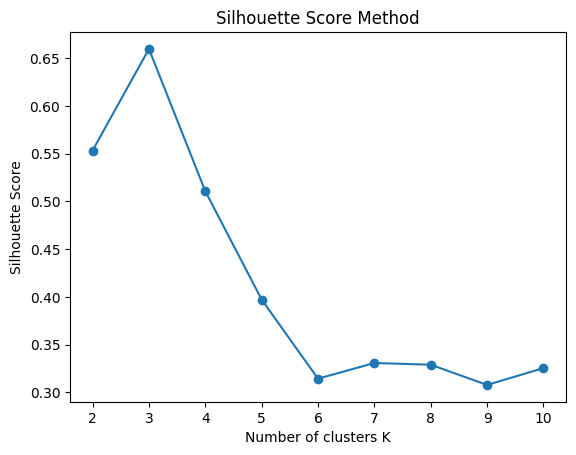

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

# Calculate silhouette scores for different values of K
for k in range(2, 11):  # Silhouette score isn't valid for K=1
    kmeans = KMeans(n_clusters=k, random_state=0)
    clusters = kmeans.fit_predict(X)
    score = silhouette_score(X, clusters)
    silhouette_scores.append(score)

# Plotting the silhouette scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters K')
plt.ylabel('Silhouette Score')
plt.show()


**What we conclude from the above graph?**

- A silhouette score of 0.65 indicates a good level of separation between the clusters. Scores above 0.5 typically suggest that the clusters are reasonably well-defined, while scores closer to 1 would indicate very well-separated clusters. Thus, a score of 0.65 suggests that the clusters are relatively distinct, making K=3 a suitable choice for the number of clusters.

- Since K=3 yields the highest silhouette score, it can be concluded that this is likely the optimal number of clusters for your dataset. This means that partitioning the data into three groups provides the best clustering solution in terms of how similar points within the same cluster are to each other compared to points in other clusters.

#### Calinski-Harabasz Index (Variance Ratio Criterion)

- The Calinski-Harabasz Index is also known as the Variance Ratio Criterion. It measures the ratio between the sum of within-cluster dispersion and between-cluster dispersion.
- Higher values indicate better cluster separation.

**Code Example for Calinski-Harabasz Index:**

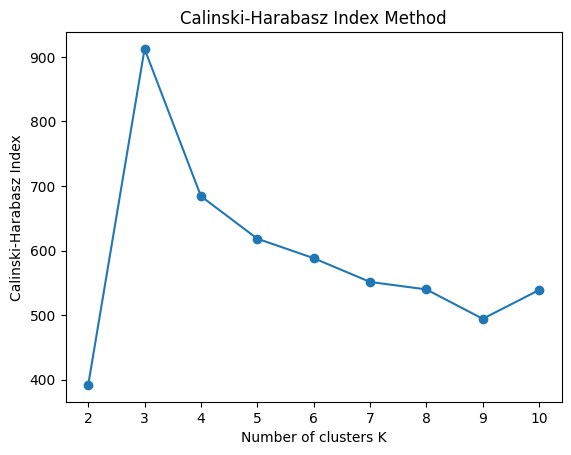

In [ ]:
from sklearn.metrics import calinski_harabasz_score

ch_scores = []

# Calculate Calinski-Harabasz score for different values of K
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=0)
    clusters = kmeans.fit_predict(X)
    score = calinski_harabasz_score(X, clusters)
    ch_scores.append(score)

# Plotting the Calinski-Harabasz score
plt.plot(range(2, 11), ch_scores, marker='o')
plt.title('Calinski-Harabasz Index Method')
plt.xlabel('Number of clusters K')
plt.ylabel('Calinski-Harabasz Index')
plt.show()


- A CH score of 900 is relatively high, suggesting that the clusters formed at K=3 are well-separated from one another. This implies that the variance between clusters is significantly larger than the variance within clusters.
- Such a score indicates that the data points within each cluster are closely packed together, and there is a clear distinction between the clusters themselves.
- Since K=3 yields the highest score, it is likely the optimal choice for clustering in this dataset. This suggests that the underlying structure of the data is best represented by three distinct groups.

### Advantages of K-Means

 K-Means clustering has several advantages that make it one of the most widely used clustering algorithms in unsupervised learning.
-  Below are the key benefits:

1. **Simplicity and Ease of Implementation**
   - K-Means is conceptually simple and easy to understand.
   - The algorithm’s steps are straightforward, involving iterative assignment of data points to clusters and recomputation of cluster centroids.
2. **Scalability**
   - K-Means is highly efficient in terms of computational complexity, especially for large datasets.
   - It has a time complexity of
O(n⋅k⋅d), where
𝑛
n is the number of data points,
𝑘
k is the number of clusters, and
𝑑
d is the dimensionality of the data.
   - This makes K-Means suitable for applications with millions of data points, especially when used with optimizations like the MiniBatch K-Means algorithm.
3. **Fast Convergence**
   - K-Means converges relatively quickly compared to other clustering algorithms.
   - It typically finds a solution after a small number of iterations, particularly with small to medium-sized datasets.
4. **Handles Large Data**
   - Due to its efficiency, K-Means can handle very large datasets that would otherwise be computationally expensive for more complex algorithms.
   - It is particularly useful for clustering in Big Data applications.

5. **Works Well for Globular Clusters**
   - K-Means is particularly well-suited for clustering data that naturally forms spherical or globular clusters.
   - When clusters have a similar size and density, K-Means performs well in discovering these structures.

### Disadvanteges of K-Means

K-Means, while popular and effective in many situations, also comes with several limitations and disadvantages.
- Here are the key disadvantages:

1. **Sensitive to Initialization**
   - The performance of K-Means largely depends on the initial placement of centroids.
   - Poor initialization can lead to suboptimal clustering (local minima), and different initializations may yield different results.
   - Techniques like K-Means++ help improve the initial centroid selection, but this issue still exists.
2. **Requires Predefining the Number of Clusters**
   - K-Means requires the number of clusters K, to be specified in advance, which may not always be intuitive or known.
   - Selecting the right number of clusters can be difficult, especially if the dataset doesn't naturally fall into a specific number of groups.
3. **Sensitive to Outliers and Noise**
   - K-Means is highly sensitive to outliers and noisy data points.
   - Outliers can significantly distort the position of the centroids, leading to poor clustering performance.
   - Techniques like K-Medoids can help mitigate this issue, but K-Means by itself struggles with it.
4. **Assumes Spherical Clusters**
   - K-Means assumes that clusters are spherical or globular in shape and of similar size.
   - It does not work well when clusters have more complex structures, such as elongated or arbitrary shapes.
   - It tends to struggle with data that has clusters of varying densities and shapes, as it is primarily distance-based.
5. **Sensitive to Scaling and Feature Weighting**
   - K-Means relies on distance metrics (usually Euclidean distance), meaning it is sensitive to how features are scaled.
   - If features have different scales (e.g., age vs. income), the clustering results may be biased.
   - Proper scaling (e.g., standardization or normalization) is necessary before applying K-Means.

## K-Medoids

- K-Medoids, also referred to as Partitioning Around Medoids (PAM), is an alternative clustering algorithm to K-Means, specifically designed to improve robustness and overcome some of the limitations of K-Means. The primary difference between K-Means and K-Medoids lies in the choice of the representative data points for each cluster.

- In K-Means, clusters are represented by centroids, which are the mean positions of all data points within a cluster. These centroids are not necessarily actual data points, but rather mathematical averages. This makes K-Means sensitive to outliers and noisy data, since centroids can be pulled towards extreme values, distorting the true shape of clusters.

- K-Medoids, on the other hand, addresses this issue by using medoids instead of centroids. A medoid is an actual data point within a dataset, making it more resistant to noise and outliers. Medoids represent the most centrally located point in a cluster, minimizing the sum of distances between itself and the other points in the cluster. This approach ensures that the cluster representative is always a real, tangible data point rather than an average, which can be skewed by anomalies or extreme values.

   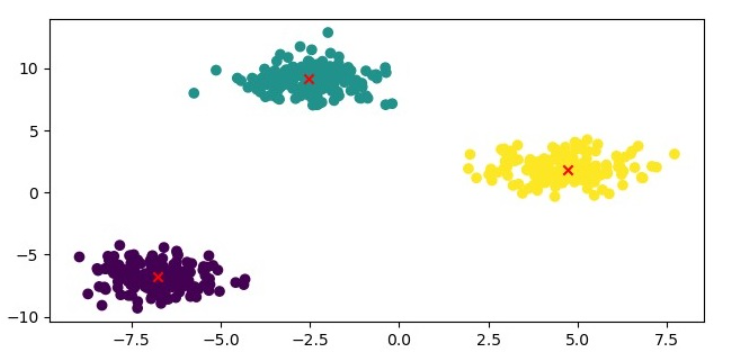

### Steps of K-Medoids algorithm

#### Initialization

- In the first step, K-Medoids begins by selecting K data points randomly from the dataset to serve as the initial medoids.
- Unlike K-Means, where centroids are computed as the mean of points in a cluster, K-Medoids selects actual data points to serve as the cluster centers.

   - Medoids: A medoid is an actual data point within the cluster that represents the central point.
   - The number of clusters, K, is predefined by the user based on prior knowledge or using methods such as the elbow method or silhouette analysis.
- Example:

   - Suppose we have 100 data points and we want to create 3 clusters. We randomly select 3 points from the dataset as initial medoids, say M1, M2, and M3.

**In the first step, K medoids are chosen randomly from the dataset. These medoids will serve as the initial representative points for each cluster.**

<ipython-input-14-67a31e74a151>:13: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')


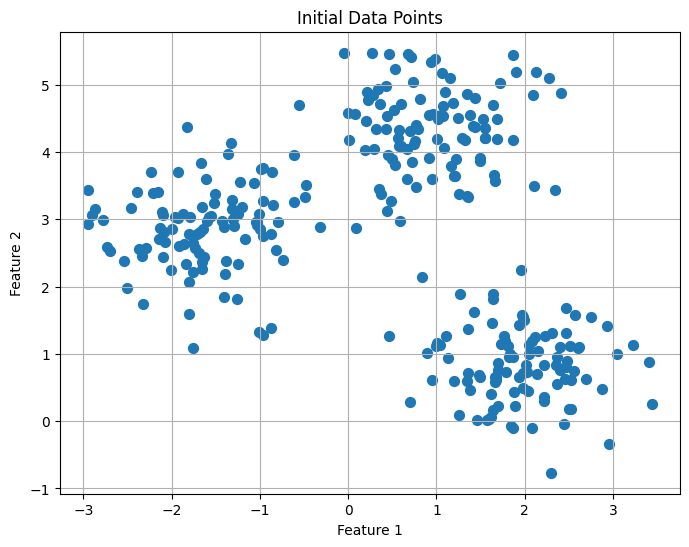

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.metrics import pairwise_distances

# Generate synthetic data
n_samples = 300
n_clusters = 3
X, _ = make_blobs(n_samples=n_samples, centers=n_clusters, cluster_std=0.60, random_state=0)

# Visualization of the initial dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis')
plt.title('Initial Data Points')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid()
plt.show()

<ipython-input-15-bac7d01aaac2>:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis', label='Data Points')


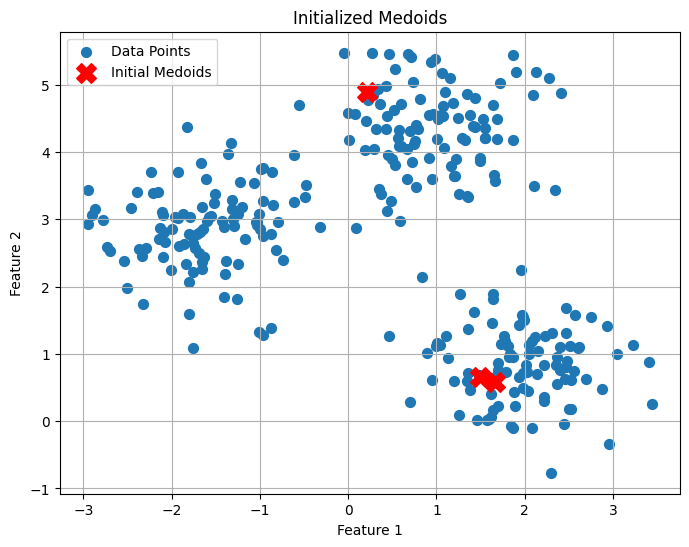

In [ ]:
# Initialize Medoids
def initialize_medoids(X, n_clusters):
    """Randomly select K data points as initial medoids."""
    random_indices = np.random.choice(X.shape[0], size=n_clusters, replace=False)
    medoids = X[random_indices]
    return medoids

medoids = initialize_medoids(X, n_clusters)

# Visualization of the initialized medoids
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50, cmap='viridis', label='Data Points')
plt.scatter(medoids[:, 0], medoids[:, 1], c='red', s=200, marker='X', label='Initial Medoids')
plt.title('Initialized Medoids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()

#### Assign Data Points to the Nearest Medoid

- Once the medoids are selected, the next step is to assign each remaining data point to its nearest medoid. The distance between the data points and medoids is calculated using a distance metric such as Euclidean distance, Manhattan distance, or any other suitable metric.

   - Nearest Medoid: A data point is assigned to the cluster of the medoid that it is closest to.
   - Each data point is associated with the medoid that minimizes the distance between the data point and the medoid.

   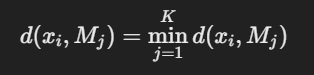

   - where M<sub>j</sub> is the medoid of cluster j.

- Example:

   - For each data point, compute the distance to M1, M2, and M3. Assign the point to the medoid with the minimum distance.

In [ ]:
# Assign Data Points to the Nearest Medoid
def assign_clusters(X, medoids):
    """Assign each data point to the nearest medoid."""
    distances = pairwise_distances(X, medoids)
    clusters = np.argmin(distances, axis=1)  # Get index of the closest medoid
    return clusters

clusters = assign_clusters(X, medoids)

#### Update Medoids

- Once the data points are assigned to clusters based on their proximity to medoids, the next step is to update the medoids. This is done by evaluating whether swapping a medoid with another data point within the same cluster can reduce the total distance or cost.

   - Cost Function: The cost of a cluster is defined as the sum of the distances between all points in the cluster and the medoid.
   - For each medoid, a potential swap is tested with every other data point in its cluster to see if replacing the medoid with another data point decreases the overall cost.
- If a swap reduces the cost, the new data point becomes the medoid. This process of swapping medoids continues until no further cost reduction can be achieved.

- Example:

   - If M1 is the medoid for cluster 1, test whether replacing M1 with another point in cluster 1 decreases the cost. If so, update the medoid.

In [ ]:
# Update Medoids
def update_medoids(X, clusters, n_clusters):
    """Update medoids to be the most central points of their respective clusters."""
    new_medoids = np.zeros((n_clusters, X.shape[1]))
    for i in range(n_clusters):
        # Get points belonging to the current cluster
        cluster_points = X[clusters == i]
        # Find the point that minimizes the total distance to all other points in the cluster
        if cluster_points.size > 0:
            distances = pairwise_distances(cluster_points, cluster_points)
            medoid_index = np.argmin(np.sum(distances, axis=1))  # Find the medoid
            new_medoids[i] = cluster_points[medoid_index]
    return new_medoids

#### Iterate Until Convergence

- Steps 3 and 4 are repeated iteratively: update the medoids and reassign data points until convergence is reached. Convergence occurs when no further medoid swaps reduce the cost, and the cluster assignments remain stable.

   - The algorithm stops when the medoids no longer change, and the clustering solution has converged to a stable state.
   - Since K-Medoids uses actual data points as medoids, it often converges slower than K-Means due to the more complex evaluation of swaps.
- Example:

   - Continue updating medoids and reassigning points until the medoids remain unchanged.

In [ ]:
 # Iterate Until Convergence
def k_medoids(X, n_clusters, max_iterations=100):
    """Perform K-Medoids clustering."""
    medoids = initialize_medoids(X, n_clusters)
    for _ in range(max_iterations):
        clusters = assign_clusters(X, medoids)
        new_medoids = update_medoids(X, clusters, n_clusters)

        # Check for convergence (if medoids do not change)
        if np.all(medoids == new_medoids):
            break
        medoids = new_medoids
    return clusters, medoids

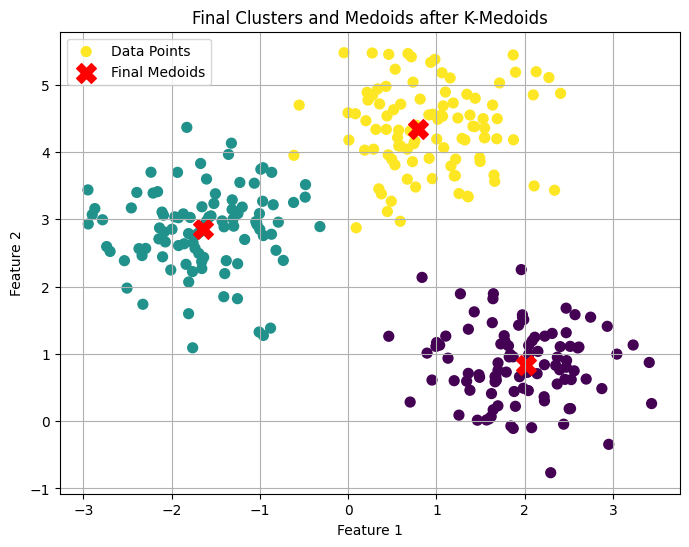

In [ ]:
# Execute K-Medoids
final_clusters, final_medoids = k_medoids(X, n_clusters)

# Step 6: Visualization of Final Clusters and Medoids
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_clusters, s=50, cmap='viridis', label='Data Points')
plt.scatter(final_medoids[:, 0], final_medoids[:, 1], c='red', s=200, marker='X', label='Final Medoids')
plt.title('Final Clusters and Medoids after K-Medoids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid()
plt.show()

### Difference from K-Means (use of medoids instead of centroids)

1. **Use of Medoids Instead of Centroids**
   - In K-Means, centroids can be located anywhere in the data space, which may lead to centroids that are not actual data points.
   - In K-Medoids, the cluster representative is always a data point from the dataset, making it more robust to noise and outliers.
2. **Handling Outliers and Non-Euclidean Distances**
   - K-Medoids is less sensitive to outliers because medoids, being actual data points, are less likely to be influenced by extreme values.
   - Unlike K-Means, K-Medoids can use non-Euclidean distance metrics, such as Manhattan distance, making it suitable for a wider range of data types (e.g., categorical data).

    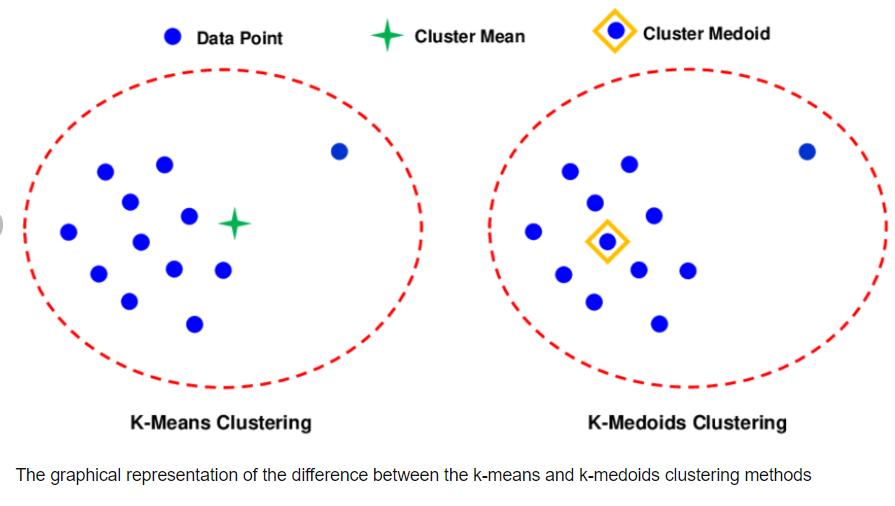

### Handling outliers and non-Euclidean distances

- In K-Medoids clustering, handling outliers and non-Euclidean distances are two critical areas where the algorithm shows a distinct advantage over K-Means.
- Here's a deeper look at how K-Medoids handles these two aspects:



#### 1. Handling Outliers in K-Medoids

Outliers are data points that deviate significantly from the rest of the dataset. In clustering, outliers can distort the representation of clusters, especially in algorithms like K-Means, where the centroid is the mean of the points in the cluster. However, K-Medoids is better suited to deal with outliers due to the following reasons:

- **Medoid as a Representative of the Cluster:**

   - Unlike K-Means, which uses a centroid (the average of all data points in the cluster), K-Medoids selects actual data points as medoids. The medoid is the point with the minimum sum of dissimilarities to all other points in the cluster. Since outliers tend to be far away from most data points, they are less likely to be chosen as medoids.
- **Reduced Sensitivity to Outliers:**

   - Since the medoid is an existing data point and not influenced by the average, K-Medoids is less sensitive to extreme values or noisy data. Outliers generally do not affect the medoid's position, as the algorithm aims to minimize the sum of distances between the medoid and the inlier points, ignoring the influence of outliers.
- **Outlier Isolation:**

   - If the dataset has a significant number of outliers, K-Medoids may isolate outliers into small clusters, making them easy to identify. Unlike K-Means, where outliers can pull centroids away from the dense clusters, K-Medoids tends to leave outliers ungrouped or clustered separately.

#### 2. Handling Non-Euclidean Distances in K-Medoids

K-Medoids is inherently more flexible than K-Means in handling non-Euclidean distances, making it suitable for datasets where Euclidean distance is not an appropriate measure of similarity.

- **Customizable Dissimilarity Measures:**

K-Meedoids can use a variety of dissimilarity measures beyond Euclidean distance. These can include:
   - Manhattan Distance (L1 norm)
   - Cosine Similarity (for text or high-dimensional data)
   - Minkowski Distance
   - Jaccard Distance (for binary or categorical data)

This flexibility allows K-Medoids to work with different types of data structures and cluster shapes that are not well represented by Euclidean distance.

- **Non-Spherical Clusters:**

   - Because K-Medoids doesn’t rely on the squared distance metric, it can handle non-spherical, irregularly shaped clusters more effectively. For example, in a dataset where clusters follow a complex, curved shape, using Manhattan or Minkowski distance in K-Medoids may yield more meaningful clusters compared to Euclidean-based K-Means.

### Pros and cons of K-Medoids compared to K-Means

#### Pros of K-Medoids

- **Robustness to Outliers and Noise:**

   - K-Medoids uses actual data points as the central representatives (medoids), making it less sensitive to outliers compared to K-Means, which uses centroids based on averages. This characteristic prevents outliers from skewing the results.
   - K-Means, in contrast, calculates centroids as the mean of all points in a cluster. If a dataset contains outliers or extreme values, these outliers can significantly distort the centroid’s position, pulling it away from the cluster's core.

  **Example:**

   - In a dataset where a few data points lie far from the main clusters, K-Medoids will likely exclude these points when calculating medoids, while K-Means may shift centroids in the direction of the outliers.

- **Ability to Work with Arbitrary Distance Metrics:**

   - K-Medoids can work with any dissimilarity metric (e.g., Euclidean distance, Manhattan distance, Cosine similarity, Jaccard distance), which makes it more flexible for non-Euclidean data.
   - K-Means relies on Euclidean distance, which may not be appropriate for datasets with non-linear relationships, categorical data, or other types of data that are not well-represented in Euclidean space.

  **Example:**

   - In text clustering or high-dimensional data, Cosine Similarity or Jaccard Distance might be more appropriate than Euclidean distance, making K-Medoids a better choice for such cases.

- **Handling Non-Spherical and Complex Cluster Shapes:**

   - K-Medoids can better handle non-spherical or irregularly shaped clusters because it doesn’t rely on the assumption that clusters are spherical or globular (as in K-Means).
   - K-Means works best when clusters are spherical, evenly sized, and have roughly the same density. If the clusters are irregular in shape, K-Means can misrepresent the cluster boundaries.

  **Example:**

   - In cases where clusters follow more complex shapes (e.g., crescent-shaped clusters or elongated clusters), K-Medoids can better capture the true shape of the clusters.

- **Interpretability of Medoids:**

   - The medoid in K-Medoids is an actual data point, which makes it more interpretable and understandable in real-world scenarios. This is particularly useful in applications where having a real data point represent the cluster is essential.
   - In K-Means, the centroid is an average of all data points in the cluster, which might not correspond to a real, physical data point. This can be less intuitive in some cases.

  **Example:**

   - In clustering customer data, a medoid can represent an actual customer, making it easier for businesses to analyze representative customer behavior, whereas a centroid would be an abstract average that may not correspond to any real customer.


#### Cons of K-Medoids

- **Higher Computational Complexity:**

   - K-Medoids is computationally more expensive compared to K-Means, especially for large datasets. This is because, in each iteration, it requires recalculating distances between every pair of data points in a cluster and potentially swapping medoids.
   - K-Means, on the other hand, is faster because updating the centroid only involves calculating the mean of the points, which is computationally simpler than recalculating distances to all points.
   
  **Example:**

   - In a large dataset with millions of points, K-Means can handle clustering more efficiently, while K-Medoids can slow down significantly due to its more complex distance computations and medoid swaps.
- **Not as Scalable for Large Datasets:**

   - Due to the higher computational burden, K-Medoids does not scale as well as K-Means for very large datasets. K-Means can quickly handle large datasets with its simple centroid-based calculations.
   - In K-Means, the simplicity of centroid updates allows it to cluster massive datasets more efficiently.

  **Example:**

   - For a dataset with millions of data points, K-Means can complete the clustering process in a shorter time, whereas K-Medoids may take longer due to the need to evaluate each medoid for every point in the cluster.
- **Sensitivity to Initialization:**

   - While K-Medoids is more robust in terms of outliers, it still shares a sensitivity to initialization with K-Means. The choice of initial medoids can impact the final clustering results, leading to different cluster formations in different runs.
   - Similarly, K-Means is also sensitive to the initial choice of centroids, although techniques like K-Means++ have been developed to mitigate this issue.

  **Example:**

   - If the initial medoids are poorly chosen, K-Medoids may converge to suboptimal clusters, just like how K-Means can converge to local optima with bad initial centroids.
- **Difficulty with Large and Complex Datasets:**

   - In some cases, K-Medoids may struggle with extremely complex or large-scale datasets, where the clusters are highly overlapping or the data structure is ambiguous.
   - K-Means, despite being more sensitive to outliers, can be a more straightforward and computationally efficient solution in such scenarios, making it a better choice for exploratory data analysis on large datasets.

  **Example:**

   - In a dataset with highly complex structures or where the number of clusters is large, K-Means can quickly give a rough estimate, while K-Medoids might struggle to converge efficiently.

## Use Case: Customer Segmentation in E-commerce

**Objective**

The primary objective of this use case is to compare the performance of K-Means and K-Medoids clustering algorithms on a synthetic dataset representing COVID-19 statistics for various countries. Specifically, the aim is to:

   - Cluster COVID-19 data into homogeneous groups to understand the underlying patterns in the dataset (e.g., countries with similar case numbers, recovery rates, etc.).
   - Analyze the impact of outliers on the clustering performance by comparing the K-Means and K-Medoids algorithms.
   - Evaluate the clustering quality using metrics such as the Elbow Method, Silhouette Score, Dunn Index, and Davies-Bouldin Index.
   - Identify the optimal number of clusters using different cluster evaluation techniques (e.g., Elbow method, Gap statistic, and Silhouette Score).
   - Compare the robustness of K-Means and K-Medoids in the presence of outliers, with the hypothesis that K-Medoids will perform better due to its resistance to outliers.

**Data Definition:**

The dataset is a synthetic COVID-19 dataset generated with features that represent real-world COVID-19 statistics for various countries. It includes both normal data points and some outliers to simulate the presence of anomalies in the data.

- Features/Columns:
   - Total Cases: The total number of confirmed COVID-19 cases for a particular country.
   - Total Deaths: The total number of deaths due to COVID-19 for a specific country.
   - Total Recovered: The total number of people who have recovered from COVID-19 in a specific country.
   - Population: The total population of the country.
   - Cases per Million: The number of COVID-19 cases per million people in a country.
   - Deaths per Million: The number of COVID-19 deaths per million people in a country.
   - Recovery Rate: The percentage of recovered cases out of the total confirmed cases for a country.
- Outliers:
   - The dataset also includes outliers (random data points with abnormally high values for all features). These outliers represent anomalous countries with extreme COVID-19 statistics (possibly due to reporting errors or unique situations) and are used to assess the algorithms' robustness.

### Data Preprocessing

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.datasets import make_blobs # import the make_blobs function

# Generate larger synthetic data
n_samples = 5000
n_features = 7
X, _ = make_blobs(n_samples=n_samples, centers=5, n_features=n_features, random_state=42)


# Normalize the dataset
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_with_outliers)

# Convert to DataFrame for better visualization
columns = ['Total Cases', 'Total Deaths', 'Total Recovered', 'Population', 'Cases per Million', 'Deaths per Million', 'Recovery Rate']
df = pd.DataFrame(X_scaled, columns=columns)
print(df.head())

   Total Cases  Total Deaths  Total Recovered  Population  Cases per Million  \
0     0.000152      0.000820         0.000546    0.001160           0.001763   
1     0.000742      0.002036         0.001031    0.001418           0.000410   
2     0.000703      0.001972         0.001396    0.001403           0.000620   
3     0.000194      0.000642         0.000448    0.001302           0.001751   
4     0.001584      0.001209         0.000965    0.000325           0.002034   

   Deaths per Million  Recovery Rate  
0            0.000365       0.001305  
1            0.000329       0.000545  
2            0.000227       0.000401  
3            0.000452       0.000938  
4            0.001519       0.000659  


In [ ]:
df.head()

,Total Cases,Total Deaths,Total Recovered,Population,Cases per Million,Deaths per Million,Recovery Rate
0,0.000152,0.000820,0.000546,0.001160,0.001763,0.000365,0.001305
1,0.000742,0.002036,0.001031,0.001418,0.000410,0.000329,0.000545
2,0.000703,0.001972,0.001396,0.001403,0.000620,0.000227,0.000401
3,0.000194,0.000642,0.000448,0.001302,0.001751,0.000452,0.000938
4,0.001584,0.001209,0.000965,0.000325,0.002034,0.001519,0.000659


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Total Cases         5050 non-null   float64
 1   Total Deaths        5050 non-null   float64
 2   Total Recovered     5050 non-null   float64
 3   Population          5050 non-null   float64
 4   Cases per Million   5050 non-null   float64
 5   Deaths per Million  5050 non-null   float64
 6   Recovery Rate       5050 non-null   float64
dtypes: float64(7)
memory usage: 276.3 KB


In [ ]:
df.describe()

,Total Cases,Total Deaths,Total Recovered,Population,Cases per Million,Deaths per Million,Recovery Rate
count,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000,5050.000000
mean,0.008449,0.008599,0.007876,0.008718,0.008418,0.008495,0.008837
std,0.076969,0.076830,0.071774,0.078768,0.074443,0.076856,0.077886
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000395,0.000513,0.000467,0.000540,0.000416,0.000390,0.000600
50%,0.000785,0.000800,0.000967,0.001185,0.001027,0.000600,0.001260
75%,0.001303,0.001483,0.001177,0.001383,0.001810,0.001736,0.001542
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Visualizing Data Distribution

**We'll visualize how the data is distributed across a few important features, such as Total Cases, Total Deaths, and Total Recovered.**

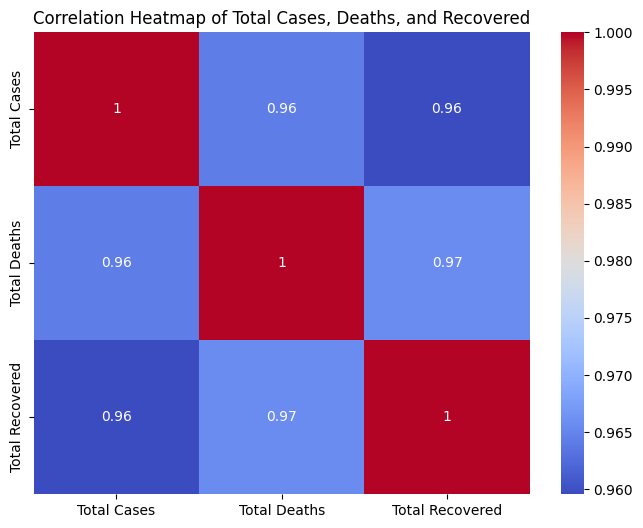

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Heatmap for correlation between Total Cases, Deaths, and Recovered
plt.figure(figsize=(8, 6))
sns.heatmap(df[['Total Cases', 'Total Deaths', 'Total Recovered']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Total Cases, Deaths, and Recovered')
plt.show()

### Finding Optimal Number of Clusters

#### Elbow Method

**We'll apply the Elbow Method to find the optimal number of clusters for K-Means.**

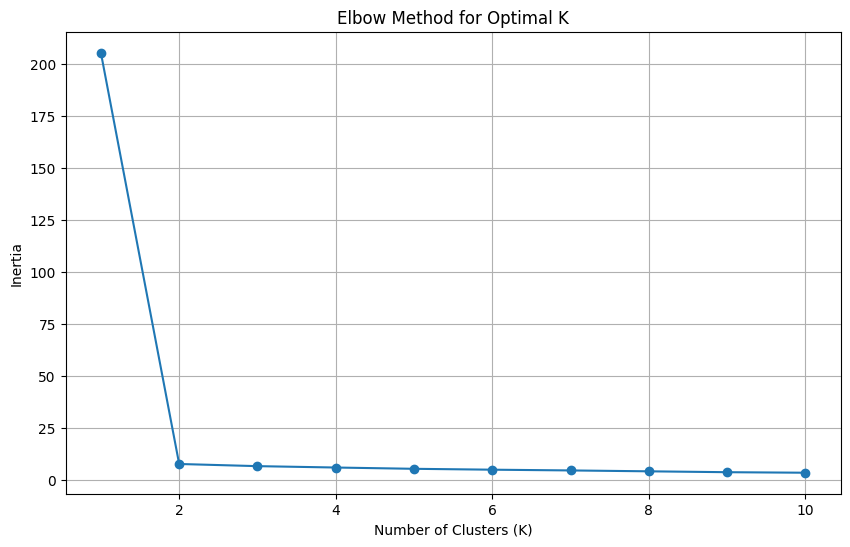

In [ ]:
from sklearn.cluster import KMeans

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

The Elbow Method shows the point where adding more clusters doesn’t significantly decrease inertia. The "elbow" typically represents the optimal number of clusters.

#### Silhouette Method

**We can also compute the silhouette scores for different values of K to evaluate how well-separated the clusters are.**

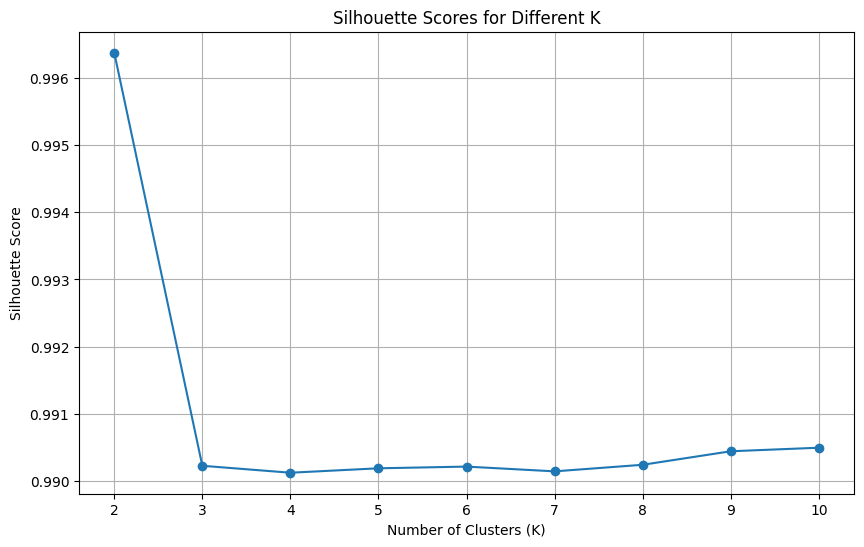

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

# start from k=2
for k in range(2, 11): # changed here
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

# Plotting Silhouette Scores
plt.figure(figsize=(10, 6))
plt.plot(range(2,11), silhouette_scores, marker='o') # changed here
plt.title('Silhouette Scores for Different K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

The silhouette score measures how close each point in one cluster is to points in the neighboring clusters. A higher score indicates well-separated clusters.

### Implement K-Means Clustering

#### Applying K-Means

Based on the elbow method and silhouette score, let's assume the optimal number of clusters is 3 (we can choose based on the results of the methods above). We'll apply K-Means clustering.

In [ ]:
# Applying K-Means clustering
optimal_k = 3  # based on the methods above
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# View the first few rows with cluster labels
print(df.head())

   Total Cases  Total Deaths  Total Recovered  Population  Cases per Million  \
0     0.000152      0.000820         0.000546    0.001160           0.001763   
1     0.000742      0.002036         0.001031    0.001418           0.000410   
2     0.000703      0.001972         0.001396    0.001403           0.000620   
3     0.000194      0.000642         0.000448    0.001302           0.001751   
4     0.001584      0.001209         0.000965    0.000325           0.002034   

   Deaths per Million  Recovery Rate  KMeans_Cluster  
0            0.000365       0.001305               0  
1            0.000329       0.000545               0  
2            0.000227       0.000401               0  
3            0.000452       0.000938               0  
4            0.001519       0.000659               0  


We assign a cluster label to each data point using fit_predict() with the chosen optimal_k.

#### Visualizing K-Means Clusters

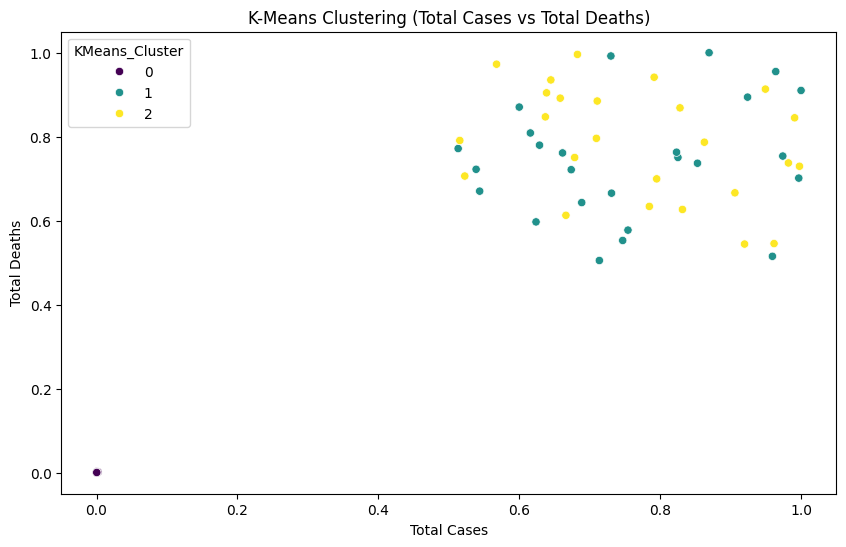

In [ ]:
# Visualizing the K-Means Clusters on two features: Total Cases and Total Deaths
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Total Cases', y='Total Deaths', hue='KMeans_Cluster', data=df, palette='viridis')
plt.title('K-Means Clustering (Total Cases vs Total Deaths)')
plt.show()

This scatter plot shows how the data points are distributed across clusters based on Total Cases and Total Deaths.

####  K-Means Evaluation (Silhouette Score)

We can evaluate the quality of K-Means clustering using the silhouette score.

In [ ]:
# Calculate the Silhouette Score for K-Means
kmeans_silhouette = silhouette_score(X_scaled, df['KMeans_Cluster'])
print(f'Silhouette Score for K-Means: {kmeans_silhouette:.2f}')

Silhouette Score for K-Means: 0.99


- This score tells us how well-separated the clusters are.
- 0.99: Shows that data points are well clustered.

### K-Medoids Clustering

 #### Applying K-Medoids

**Now we apply K-Medoids clustering on the same dataset.**

In [ ]:
from sklearn_extra.cluster import KMedoids

# Applying K-Medoids clustering
kmedoids = KMedoids(n_clusters=optimal_k, random_state=42)
df['KMedoids_Cluster'] = kmedoids.fit_predict(X_scaled)

# View the first few rows with cluster labels
print(df.head())

   Total Cases  Total Deaths  Total Recovered  Population  Cases per Million  \
0     0.000152      0.000820         0.000546    0.001160           0.001763   
1     0.000742      0.002036         0.001031    0.001418           0.000410   
2     0.000703      0.001972         0.001396    0.001403           0.000620   
3     0.000194      0.000642         0.000448    0.001302           0.001751   
4     0.001584      0.001209         0.000965    0.000325           0.002034   

   Deaths per Million  Recovery Rate  KMeans_Cluster  KMedoids_Cluster  
0            0.000365       0.001305               0                 0  
1            0.000329       0.000545               0                 0  
2            0.000227       0.000401               0                 0  
3            0.000452       0.000938               0                 0  
4            0.001519       0.000659               0                 0  


K-Medoids is less sensitive to outliers since it uses actual data points (medoids) as cluster centers.

####  Visualizing K-Medoids Clusters

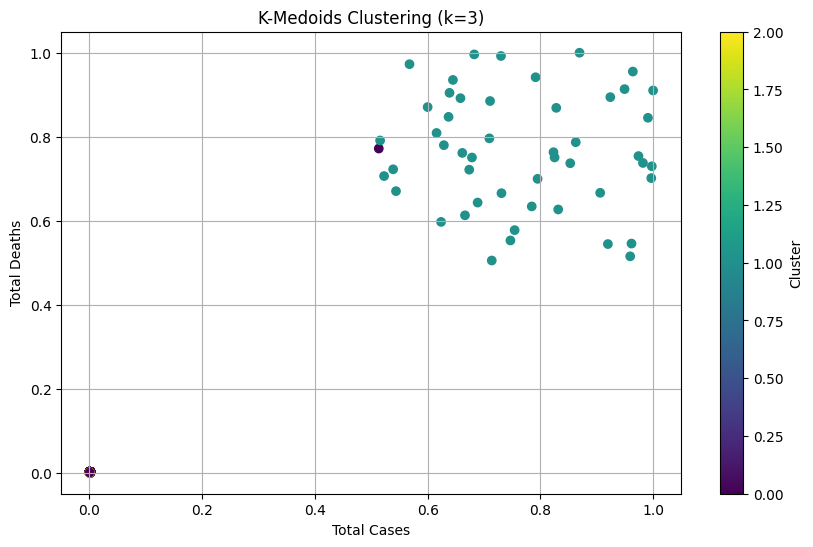

In [ ]:
# Import the required libraries
from sklearn_extra.cluster import KMedoids
import matplotlib.pyplot as plt

# Create K-Medoids model for k=3
kmedoids = KMedoids(n_clusters=3, random_state=42)

# Fit the model
kmedoids.fit(X_scaled)

# Predict the cluster labels
labels = kmedoids.labels_

# Add cluster labels to the original DataFrame
df['Cluster'] = labels

# Visualize the clusters for the first two features (Total Cases and Total Deaths)
plt.figure(figsize=(10, 6))
plt.scatter(df['Total Cases'], df['Total Deaths'], c=df['Cluster'], cmap='viridis', marker='o')
plt.title('K-Medoids Clustering (k=3)')
plt.xlabel('Total Cases')
plt.ylabel('Total Deaths')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

This scatter plot visualizes how the data points are grouped by K-Medoids based on Total Cases and Total Deaths.

 #### K-Medoids Evaluation (Silhouette Score)

**Let's calculate the silhouette score for the K-Medoids clustering to compare it with K-Means.**

In [ ]:
# Calculate the Silhouette Score for K-Medoids
kmedoids_silhouette = silhouette_score(X_scaled, df['KMedoids_Cluster'])
print(f'Silhouette Score for K-Medoids: {kmedoids_silhouette:.2f}')

Silhouette Score for K-Medoids: -0.14


In this case clusters are not well-seperated from each other.

### Conclusion

In the analysis of the synthetic COVID-19 dataset using both K-Means and K-Medoids clustering algorithms, we obtained the following results:

**K-Means Clustering:**

- Silhouette Score: 0.99
   - The high silhouette score indicates that the clusters formed by K-Means are well-separated and tightly packed. This suggests that the data points within each cluster are similar to each other while being distinct from points in other clusters. The K-Means algorithm effectively captures the underlying structure of the data, making it a suitable choice for this dataset.

**K-Medoids Clustering:**

- Silhouette Score: -0.14
   - The negative silhouette score for K-Medoids indicates that the clusters are poorly separated, and many data points are closer to clusters other than their assigned ones. This suggests that K-Medoids struggled to find representative points (medoids) that accurately reflect the central tendency of the clusters, possibly due to the presence of outliers in the dataset.

#### Implications of the Findings:

- Robustness to Outliers: While K-Medoids is generally more robust to outliers compared to K-Means, the presence of outliers in this synthetic dataset adversely affected its performance. In cases where the dataset contains significant outliers, K-Medoids may not always yield better clustering results than K-Means.

- Algorithm Suitability: The choice of clustering algorithm is critical and should be informed by the dataset's characteristics. For this synthetic COVID-19 dataset, K-Means outperformed K-Medoids, suggesting that K-Means is better suited for datasets where clusters are clearly defined without excessive influence from outliers.

- Further Investigation: The findings highlight the importance of evaluating different clustering algorithms, especially when dealing with real-world data that may include noise and outliers. Future studies may explore additional preprocessing techniques, such as outlier removal or data transformation, to enhance the performance of K-Medoids.

**Overall, the use case demonstrates the significance of understanding the strengths and weaknesses of clustering algorithms in the context of specific datasets, guiding practitioners in making informed decisions in their analyses.**